## OFT 训练指标可视化（metrics.csv）

- 读取：`_OFT/outputs/<run>/logs/metrics.csv`
- 输出：保存到各 run 目录下的 `figures/`

建议在 repo 根目录打开 notebook，并把工作目录切到 `_OFT/bestcheckpoint` 后运行。


In [ ]:
from __future__ import annotations

from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import pandas as pd

# Run this notebook with working directory at `_OFT/bestcheckpoint`.
OUTPUTS_DIR = Path("../outputs").resolve()

# Explicitly list runs (recommended). Use folder names under OUTPUTS_DIR.
RUN_DIRS: list[str] = [
    # "sd15_oft_run1",
    "sd35m_std-s_exp",
]
AUTO_DISCOVER = False

SMOOTH_WINDOW = 10

pd.set_option("display.max_rows", 200)
plt.rcParams["figure.dpi"] = 120


In [ ]:
def discover_runs(outputs_dir: Path) -> list[Path]:
    runs: list[Path] = []
    for p in sorted(outputs_dir.iterdir()):
        if not p.is_dir():
            continue
        metrics = p / "logs" / "metrics.csv"
        if metrics.exists():
            runs.append(p)
    return runs


def resolve_run_dirs(outputs_dir: Path, run_dirs: list[str], *, auto_discover: bool) -> list[Path]:
    if run_dirs:
        resolved: list[Path] = []
        for r in run_dirs:
            p = Path(r)
            if not p.is_absolute():
                p = outputs_dir / p
            p = p.resolve()
            metrics = p / "logs" / "metrics.csv"
            if not metrics.exists():
                raise FileNotFoundError(f"metrics.csv not found: {metrics}")
            resolved.append(p)
        return resolved

    if auto_discover:
        runs = discover_runs(outputs_dir)
        if not runs:
            raise FileNotFoundError(f"No runs found under: {outputs_dir}")
        return runs

    raise ValueError("Please set RUN_DIRS (recommended), or set AUTO_DISCOVER=True")


def load_metrics(run_dir: Path) -> pd.DataFrame:
    metrics_path = run_dir / "logs" / "metrics.csv"
    df = pd.read_csv(metrics_path)

    expected_cols = [
        "timestamp",
        "global_step",
        "loss",
        "grad_norm_pre_clip",
        "step_seconds",
        "total_seconds",
    ]
    for c in expected_cols:
        if c not in df.columns:
            df[c] = pd.NA

    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
    df["global_step"] = pd.to_numeric(df["global_step"], errors="coerce")
    df["loss"] = pd.to_numeric(df["loss"], errors="coerce")
    df["grad_norm_pre_clip"] = pd.to_numeric(df["grad_norm_pre_clip"], errors="coerce")
    df["step_seconds"] = pd.to_numeric(df["step_seconds"], errors="coerce")
    df["total_seconds"] = pd.to_numeric(df["total_seconds"], errors="coerce")

    return df


runs = resolve_run_dirs(OUTPUTS_DIR, RUN_DIRS, auto_discover=AUTO_DISCOVER)
print("Selected runs:", [p.name for p in runs])


In [ ]:
def plot_metric_panels(df: pd.DataFrame, *, smooth_window: int, title: str):
    d = df.sort_values("global_step").copy()

    if smooth_window and smooth_window > 1:
        d["loss_smooth"] = d["loss"].rolling(smooth_window, min_periods=1).mean()
        d["grad_norm_smooth"] = d["grad_norm_pre_clip"].rolling(smooth_window, min_periods=1).mean()
    else:
        d["loss_smooth"] = d["loss"]
        d["grad_norm_smooth"] = d["grad_norm_pre_clip"]

    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

    axes[0].plot(d["global_step"], d["loss"], alpha=0.25, label="loss")
    axes[0].plot(d["global_step"], d["loss_smooth"], linewidth=2.0, label=f"loss (smooth={smooth_window})")
    axes[0].set_ylabel("loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(d["global_step"], d["grad_norm_pre_clip"], alpha=0.25, label="grad_norm_pre_clip")
    axes[1].plot(d["global_step"], d["grad_norm_smooth"], linewidth=2.0, label=f"grad_norm (smooth={smooth_window})")
    axes[1].set_ylabel("grad_norm")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    axes[2].plot(d["global_step"], d["step_seconds"], label="step_seconds")
    axes[2].set_ylabel("sec/step")
    axes[2].set_xlabel("global_step")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    fig.suptitle(title)
    fig.tight_layout()
    return fig


def overlay_metric(
    runs: list[Path],
    *,
    metric: Literal["loss", "grad_norm_pre_clip", "step_seconds"] = "loss",
    smooth_window: int = 10,
    max_runs: int | None = 6,
    title: str | None = None,
):
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    selected = runs if max_runs is None else runs[:max_runs]
    for run_dir in selected:
        d = load_metrics(run_dir).sort_values("global_step")
        if d.empty:
            continue
        y = (
            d[metric].rolling(smooth_window, min_periods=1).mean()
            if smooth_window and smooth_window > 1
            else d[metric]
        )
        ax.plot(d["global_step"], y, label=run_dir.name)

    ax.set_xlabel("global_step")
    ax.set_ylabel(f"{metric} (smoothed={smooth_window})" if smooth_window > 1 else metric)
    ax.grid(True, alpha=0.3)
    ax.legend()
    if title:
        ax.set_title(title)
    fig.tight_layout()
    return fig


# Save plots under each run_dir/figures/
for run_dir in runs:
    df_run = load_metrics(run_dir)
    fig_dir = run_dir / "figures"
    fig_dir.mkdir(parents=True, exist_ok=True)

    fig1 = plot_metric_panels(df_run, smooth_window=SMOOTH_WINDOW, title=run_dir.name)
    p1 = fig_dir / "metrics.png"
    fig1.savefig(p1)

    fig2 = overlay_metric(runs, metric="loss", smooth_window=max(1, SMOOTH_WINDOW * 2), title="overlay_loss")
    p2 = fig_dir / "overlay_loss.png"
    fig2.savefig(p2)

    print("Saved:", p1)
    print("Saved:", p2)


## OFT 训练指标可视化（metrics.csv）

- 读取：`_OFT/outputs/<run>/logs/metrics.csv`
- 输出：保存到各 run 目录下的 `figures/`

建议在 repo 根目录打开 notebook，并把工作目录切到 `_OFT/bestcheckpoint` 后运行。


In [ ]:
from __future__ import annotations

from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import pandas as pd

# Run this notebook with working directory at `_OFT/bestcheckpoint`.
OUTPUTS_DIR = Path("../outputs").resolve()

# Explicitly list runs (recommended). Use folder names under OUTPUTS_DIR.
RUN_DIRS: list[str] = [
    # "sd15_oft_run1",
    "sd35m_std-s_exp",
]
AUTO_DISCOVER = False

SMOOTH_WINDOW = 10

pd.set_option("display.max_rows", 200)
plt.rcParams["figure.dpi"] = 120


In [ ]:
def discover_runs(outputs_dir: Path) -> list[Path]:
    runs: list[Path] = []
    for p in sorted(outputs_dir.iterdir()):
        if not p.is_dir():
            continue
        metrics = p / "logs" / "metrics.csv"
        if metrics.exists():
            runs.append(p)
    return runs


def resolve_run_dirs(outputs_dir: Path, run_dirs: list[str], *, auto_discover: bool) -> list[Path]:
    if run_dirs:
        resolved: list[Path] = []
        for r in run_dirs:
            p = Path(r)
            if not p.is_absolute():
                p = outputs_dir / p
            p = p.resolve()
            metrics = p / "logs" / "metrics.csv"
            if not metrics.exists():
                raise FileNotFoundError(f"metrics.csv not found: {metrics}")
            resolved.append(p)
        return resolved

    if auto_discover:
        runs = discover_runs(outputs_dir)
        if not runs:
            raise FileNotFoundError(f"No runs found under: {outputs_dir}")
        return runs

    raise ValueError("Please set RUN_DIRS (recommended), or set AUTO_DISCOVER=True")


def load_metrics(run_dir: Path) -> pd.DataFrame:
    metrics_path = run_dir / "logs" / "metrics.csv"
    df = pd.read_csv(metrics_path)

    expected_cols = [
        "timestamp",
        "global_step",
        "loss",
        "grad_norm_pre_clip",
        "step_seconds",
        "total_seconds",
    ]
    for c in expected_cols:
        if c not in df.columns:
            df[c] = pd.NA

    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
    df["global_step"] = pd.to_numeric(df["global_step"], errors="coerce")
    df["loss"] = pd.to_numeric(df["loss"], errors="coerce")
    df["grad_norm_pre_clip"] = pd.to_numeric(df["grad_norm_pre_clip"], errors="coerce")
    df["step_seconds"] = pd.to_numeric(df["step_seconds"], errors="coerce")
    df["total_seconds"] = pd.to_numeric(df["total_seconds"], errors="coerce")

    return df


runs = resolve_run_dirs(OUTPUTS_DIR, RUN_DIRS, auto_discover=AUTO_DISCOVER)
print("Selected runs:", [p.name for p in runs])


In [ ]:
def plot_metric_panels(df: pd.DataFrame, *, smooth_window: int, title: str):
    d = df.sort_values("global_step").copy()

    if smooth_window and smooth_window > 1:
        d["loss_smooth"] = d["loss"].rolling(smooth_window, min_periods=1).mean()
        d["grad_norm_smooth"] = d["grad_norm_pre_clip"].rolling(smooth_window, min_periods=1).mean()
    else:
        d["loss_smooth"] = d["loss"]
        d["grad_norm_smooth"] = d["grad_norm_pre_clip"]

    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

    axes[0].plot(d["global_step"], d["loss"], alpha=0.25, label="loss")
    axes[0].plot(d["global_step"], d["loss_smooth"], linewidth=2.0, label=f"loss (smooth={smooth_window})")
    axes[0].set_ylabel("loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(d["global_step"], d["grad_norm_pre_clip"], alpha=0.25, label="grad_norm_pre_clip")
    axes[1].plot(d["global_step"], d["grad_norm_smooth"], linewidth=2.0, label=f"grad_norm (smooth={smooth_window})")
    axes[1].set_ylabel("grad_norm")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    axes[2].plot(d["global_step"], d["step_seconds"], label="step_seconds")
    axes[2].set_ylabel("sec/step")
    axes[2].set_xlabel("global_step")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    fig.suptitle(title)
    fig.tight_layout()
    return fig


def overlay_metric(
    runs: list[Path],
    *,
    metric: Literal["loss", "grad_norm_pre_clip", "step_seconds"] = "loss",
    smooth_window: int = 10,
    max_runs: int | None = 6,
    title: str | None = None,
):
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    selected = runs if max_runs is None else runs[:max_runs]
    for run_dir in selected:
        d = load_metrics(run_dir).sort_values("global_step")
        if d.empty:
            continue
        y = (
            d[metric].rolling(smooth_window, min_periods=1).mean()
            if smooth_window and smooth_window > 1
            else d[metric]
        )
        ax.plot(d["global_step"], y, label=run_dir.name)

    ax.set_xlabel("global_step")
    ax.set_ylabel(f"{metric} (smoothed={smooth_window})" if smooth_window > 1 else metric)
    ax.grid(True, alpha=0.3)
    ax.legend()
    if title:
        ax.set_title(title)
    fig.tight_layout()
    return fig


# Save plots under each run_dir/figures/
for run_dir in runs:
    df_run = load_metrics(run_dir)
    fig_dir = run_dir / "figures"
    fig_dir.mkdir(parents=True, exist_ok=True)

    fig1 = plot_metric_panels(df_run, smooth_window=SMOOTH_WINDOW, title=run_dir.name)
    p1 = fig_dir / "metrics.png"
    fig1.savefig(p1)

    fig2 = overlay_metric(runs, metric="loss", smooth_window=max(1, SMOOTH_WINDOW * 2), title="overlay_loss")
    p2 = fig_dir / "overlay_loss.png"
    fig2.savefig(p2)

    print("Saved:", p1)
    print("Saved:", p2)


## OFT 训练指标可视化（metrics.csv）

读取 `_OFT/outputs/<run>/logs/metrics.csv` 并绘制 loss / grad_norm / step_seconds 等曲线。

- 建议在 repo 根目录打开 notebook，并将工作目录切到 `_OFT/bestcheckpoint` 后运行。


In [ ]:
from __future__ import annotations

from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import pandas as pd

# run this notebook with working directory at `_OFT/bestcheckpoint`
OUTPUTS_DIR = Path("../outputs").resolve()

RUN_DIRS: list[str] = [
    # "sd15_oft_run1",
    "sd35m_std-s_exp",
]
AUTO_DISCOVER = False

SMOOTH_WINDOW = 10
OVERLAY_SMOOTH_WINDOW = 20

pd.set_option("display.max_rows", 200)
plt.rcParams["figure.dpi"] = 120


In [ ]:
def discover_runs(outputs_dir: Path) -> list[Path]:
    runs: list[Path] = []
    for p in sorted(outputs_dir.iterdir()):
        if not p.is_dir():
            continue
        metrics = p / "logs" / "metrics.csv"
        if metrics.exists():
            runs.append(p)
    return runs


def resolve_run_dirs(outputs_dir: Path, run_dirs: list[str], *, auto_discover: bool) -> list[Path]:
    if run_dirs:
        resolved: list[Path] = []
        for r in run_dirs:
            p = Path(r)
            if not p.is_absolute():
                p = outputs_dir / p
            p = p.resolve()
            metrics = p / "logs" / "metrics.csv"
            if not metrics.exists():
                raise FileNotFoundError(f"metrics.csv not found: {metrics}")
            resolved.append(p)
        return resolved

    if auto_discover:
        runs = discover_runs(outputs_dir)
        if not runs:
            raise FileNotFoundError(f"No runs found under: {outputs_dir}")
        return runs

    raise ValueError("Please set RUN_DIRS (recommended), or set AUTO_DISCOVER=True")


def load_metrics(run_dir: Path) -> pd.DataFrame:
    metrics_path = run_dir / "logs" / "metrics.csv"
    df = pd.read_csv(metrics_path)

    expected_cols = [
        "timestamp",
        "global_step",
        "loss",
        "grad_norm_pre_clip",
        "step_seconds",
        "total_seconds",
    ]
    for c in expected_cols:
        if c not in df.columns:
            df[c] = pd.NA

    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
    df["global_step"] = pd.to_numeric(df["global_step"], errors="coerce")
    df["loss"] = pd.to_numeric(df["loss"], errors="coerce")
    df["grad_norm_pre_clip"] = pd.to_numeric(df["grad_norm_pre_clip"], errors="coerce")
    df["step_seconds"] = pd.to_numeric(df["step_seconds"], errors="coerce")
    df["total_seconds"] = pd.to_numeric(df["total_seconds"], errors="coerce")

    return df


runs = resolve_run_dirs(OUTPUTS_DIR, RUN_DIRS, auto_discover=AUTO_DISCOVER)
print("Selected runs:", [p.name for p in runs])


In [ ]:
def plot_metrics(df: pd.DataFrame, *, smooth_window: int = 1, title: str = ""):
    d = df.sort_values("global_step").copy()

    if smooth_window and smooth_window > 1:
        d["loss_smooth"] = d["loss"].rolling(smooth_window, min_periods=1).mean()
        d["grad_norm_smooth"] = d["grad_norm_pre_clip"].rolling(smooth_window, min_periods=1).mean()
    else:
        d["loss_smooth"] = d["loss"]
        d["grad_norm_smooth"] = d["grad_norm_pre_clip"]

    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

    axes[0].plot(d["global_step"], d["loss"], alpha=0.25, label="loss")
    axes[0].plot(d["global_step"], d["loss_smooth"], linewidth=2.0, label=f"loss (smooth={smooth_window})")
    axes[0].set_ylabel("loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(d["global_step"], d["grad_norm_pre_clip"], alpha=0.25, label="grad_norm_pre_clip")
    axes[1].plot(d["global_step"], d["grad_norm_smooth"], linewidth=2.0, label=f"grad_norm (smooth={smooth_window})")
    axes[1].set_ylabel("grad_norm")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    axes[2].plot(d["global_step"], d["step_seconds"], label="step_seconds")
    axes[2].set_ylabel("sec/step")
    axes[2].set_xlabel("global_step")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    if title:
        fig.suptitle(title)
    fig.tight_layout()
    return fig


for run_dir in runs:
    df_run = load_metrics(run_dir)
    fig_dir = run_dir / "figures"
    fig_dir.mkdir(parents=True, exist_ok=True)

    fig = plot_metrics(df_run, smooth_window=SMOOTH_WINDOW, title=str(run_dir.name))
    out_path = fig_dir / "metrics.png"
    fig.savefig(out_path)
    print("Saved:", out_path)


<!-- # OFT 训练指标可视化（metrics.csv）

这个 notebook 用于读取 `outputs/<run>/logs/metrics.csv` 并绘制：

- `loss` 曲线（含可选平滑）
- `grad_norm_pre_clip` 曲线
- `step_seconds` / `total_seconds` 耗时曲线
- 多个 run 的曲线对比

> 约定：每个 run 目录下存在 `logs/metrics.csv`，列为：
> `timestamp,global_step,loss,grad_norm_pre_clip,step_seconds,total_seconds` -->


In [85]:
from __future__ import annotations

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# NOTE: run this notebook with working directory at `_OFT/bestcheckpoint`.
OUTPUTS_DIR = Path("../outputs").resolve()

# 显式指定要看的 run（推荐）：
# - 写子目录名（相对 OUTPUTS_DIR），或写绝对路径
# - 只会读取这里列出的 runs，不会扫描整个 outputs/
RUN_DIRS: list[str] = [

    "sd35m_std-s_exp",
    # "sd35m_std-s_half",
]

# 如果你暂时想自动发现（会扫描 outputs/），把它设为 True
AUTO_DISCOVER = False

pd.set_option("display.max_rows", 200)
plt.rcParams["figure.dpi"] = 120


In [86]:
SMOOTH_WINDOW = 10
OVERLAY_SMOOTH_WINDOW = 20

In [87]:
def discover_runs(outputs_dir: Path) -> list[Path]:
    runs: list[Path] = []
    for p in sorted(outputs_dir.iterdir()):
        if not p.is_dir():
            continue
        metrics = p / "logs" / "metrics.csv"
        if metrics.exists():
            runs.append(p)
    return runs


def resolve_run_dirs(outputs_dir: Path, run_dirs: list[str], *, auto_discover: bool) -> list[Path]:
    if run_dirs:
        resolved: list[Path] = []
        for r in run_dirs:
            p = Path(r)
            if not p.is_absolute():
                p = outputs_dir / p
            p = p.resolve()
            metrics = p / "logs" / "metrics.csv"
            if not metrics.exists():
                raise FileNotFoundError(f"metrics.csv not found: {metrics}")
            resolved.append(p)
        return resolved

    if auto_discover:
        runs = discover_runs(outputs_dir)
        if not runs:
            raise FileNotFoundError(f"No runs found under: {outputs_dir}")
        return runs

    raise ValueError("Please set RUN_DIRS (recommended), or set AUTO_DISCOVER=True")


def load_metrics(run_dir: Path) -> pd.DataFrame:
    metrics_path = run_dir / "logs" / "metrics.csv"
    df = pd.read_csv(metrics_path)

    # 兼容不同版本的 metrics.csv：缺列时补齐，避免后续 KeyError
    expected_cols = [
        "timestamp",
        "global_step",
        "loss",
        "grad_norm_pre_clip",
        "step_seconds",
        "total_seconds",
    ]
    for c in expected_cols:
        if c not in df.columns:
            df[c] = pd.NA

    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
    df["global_step"] = pd.to_numeric(df["global_step"], errors="coerce")
    df["loss"] = pd.to_numeric(df["loss"], errors="coerce")

    # grad_norm_pre_clip 可能是空字符串 -> NaN
    df["grad_norm_pre_clip"] = pd.to_numeric(df["grad_norm_pre_clip"], errors="coerce")
    df["step_seconds"] = pd.to_numeric(df["step_seconds"], errors="coerce")
    df["total_seconds"] = pd.to_numeric(df["total_seconds"], errors="coerce")

    return df


runs = resolve_run_dirs(OUTPUTS_DIR, RUN_DIRS, auto_discover=AUTO_DISCOVER)
runs


[PosixPath('/mnt/workspace/xiepeixing/Project/_TestProject/OFT/_OFT/outputs/sd35m_std-s_exp')]

In [88]:
# 选择要绘制的 runs（每个 run 会单独出图，最后再输出合并对比图）
assert runs, "No runs selected"

print("Selected runs:", [p.name for p in runs])

# 仅用于在 notebook 里快速预览一下数据
PRIMARY_RUN_DIR = runs[0]
df_primary = load_metrics(PRIMARY_RUN_DIR)
print("Primary preview run:", PRIMARY_RUN_DIR)
df_primary.head()

Selected runs: ['sd35m_std-s_exp']
Primary preview run: /mnt/workspace/xiepeixing/Project/_TestProject/OFT/_OFT/outputs/sd35m_std-s_exp


,timestamp,global_step,loss,grad_norm_pre_clip,step_seconds,total_seconds
0,2026-03-21 17:27:58.778904+00:00,1,0.291778,0.033481,30.612900,30.612900
1,2026-03-21 17:28:04.135166+00:00,2,0.312114,0.021102,5.356263,35.969162
2,2026-03-21 17:28:09.506110+00:00,3,0.324562,0.032428,5.370945,41.340107
3,2026-03-21 17:28:14.859476+00:00,4,0.260365,0.033950,5.353366,46.693474
4,2026-03-21 17:28:20.209336+00:00,5,0.378309,0.080101,5.349859,52.043333


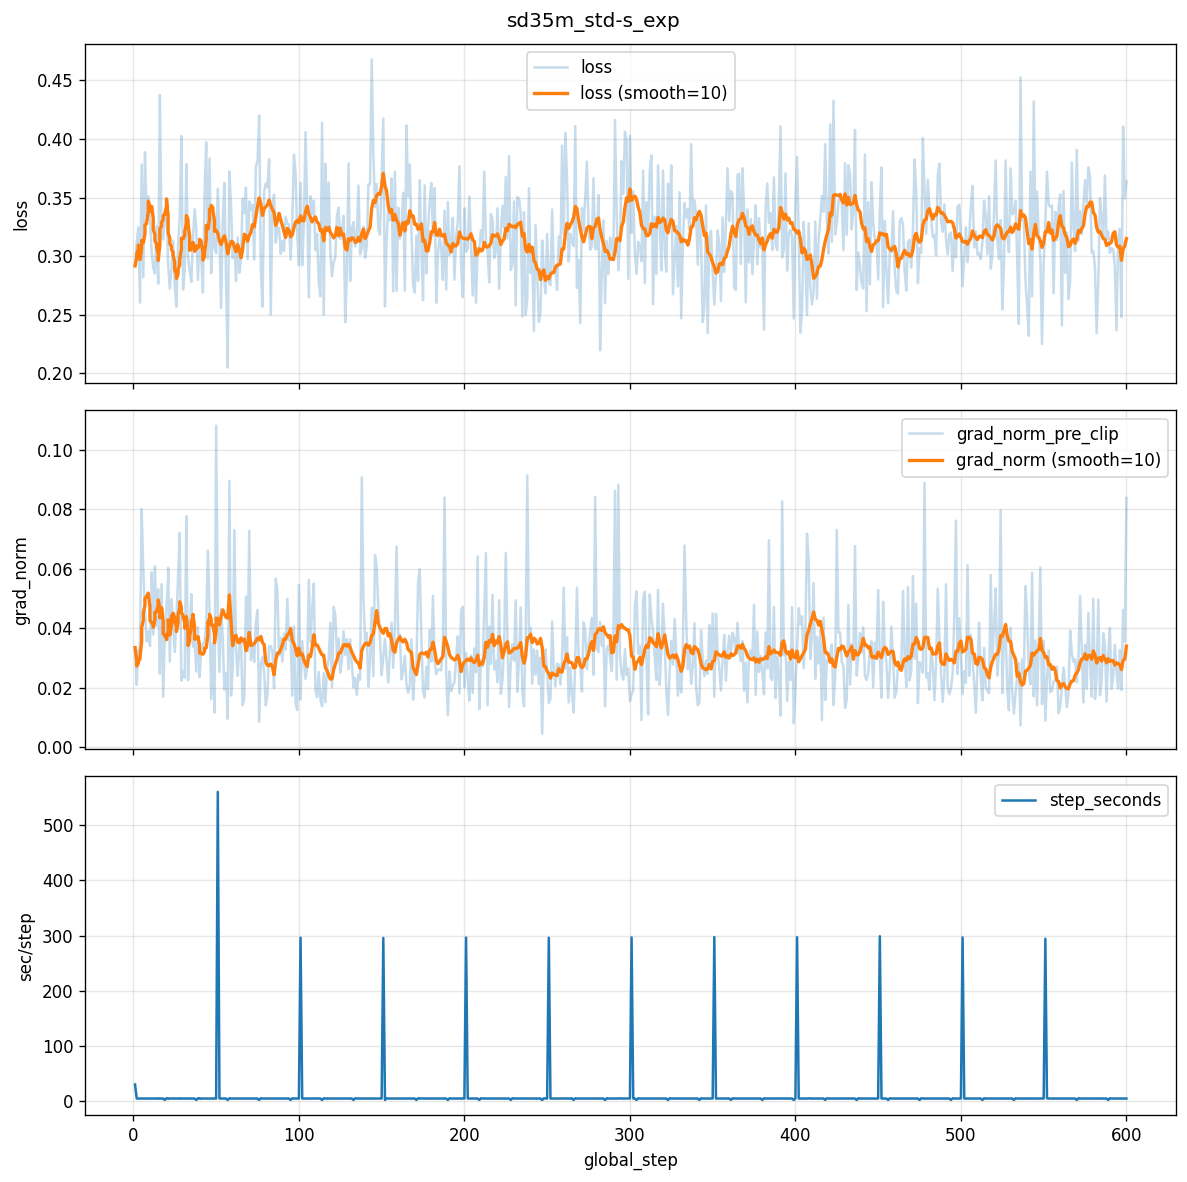

In [89]:
def plot_metrics(df: pd.DataFrame, *, smooth_window: int = 1, title: str = ""):
    d = df.sort_values("global_step").copy()

    if smooth_window and smooth_window > 1:
        d["loss_smooth"] = d["loss"].rolling(smooth_window, min_periods=1).mean()
        d["grad_norm_smooth"] = d["grad_norm_pre_clip"].rolling(smooth_window, min_periods=1).mean()
    else:
        d["loss_smooth"] = d["loss"]
        d["grad_norm_smooth"] = d["grad_norm_pre_clip"]

    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

    axes[0].plot(d["global_step"], d["loss"], alpha=0.25, label="loss")
    axes[0].plot(d["global_step"], d["loss_smooth"], linewidth=2.0, label=f"loss (smooth={smooth_window})")
    axes[0].set_ylabel("loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(d["global_step"], d["grad_norm_pre_clip"], alpha=0.25, label="grad_norm_pre_clip")
    axes[1].plot(d["global_step"], d["grad_norm_smooth"], linewidth=2.0, label=f"grad_norm (smooth={smooth_window})")
    axes[1].set_ylabel("grad_norm")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    axes[2].plot(d["global_step"], d["step_seconds"], label="step_seconds")
    axes[2].set_ylabel("sec/step")
    axes[2].set_xlabel("global_step")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    if title:
        fig.suptitle(title)
    fig.tight_layout()
    return fig


# # 预览：primary run 的指标曲线
# plot_metrics(df_primary, smooth_window=10, title=str(PRIMARY_RUN_DIR.name))

# 1) 每个 run 单独出图（保存到各自 run_dir/figures/）
for run_dir in runs:
    df_run = load_metrics(run_dir)
    fig_dir = run_dir / "figures"
    fig_dir.mkdir(parents=True, exist_ok=True)

    plot_metrics(df_run, smooth_window=SMOOTH_WINDOW, title=str(run_dir.name))

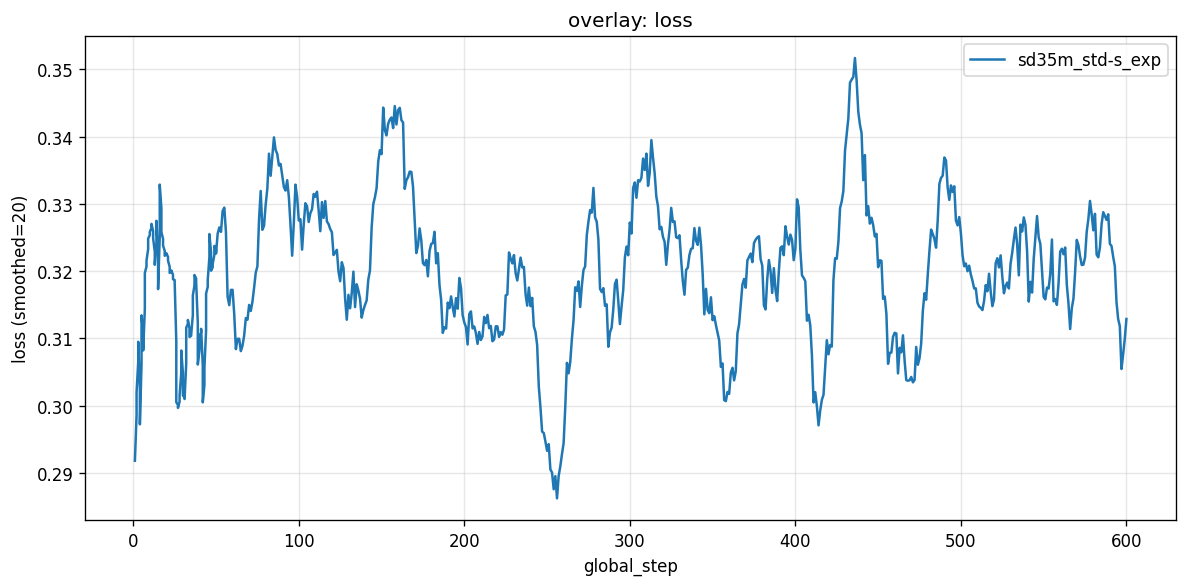

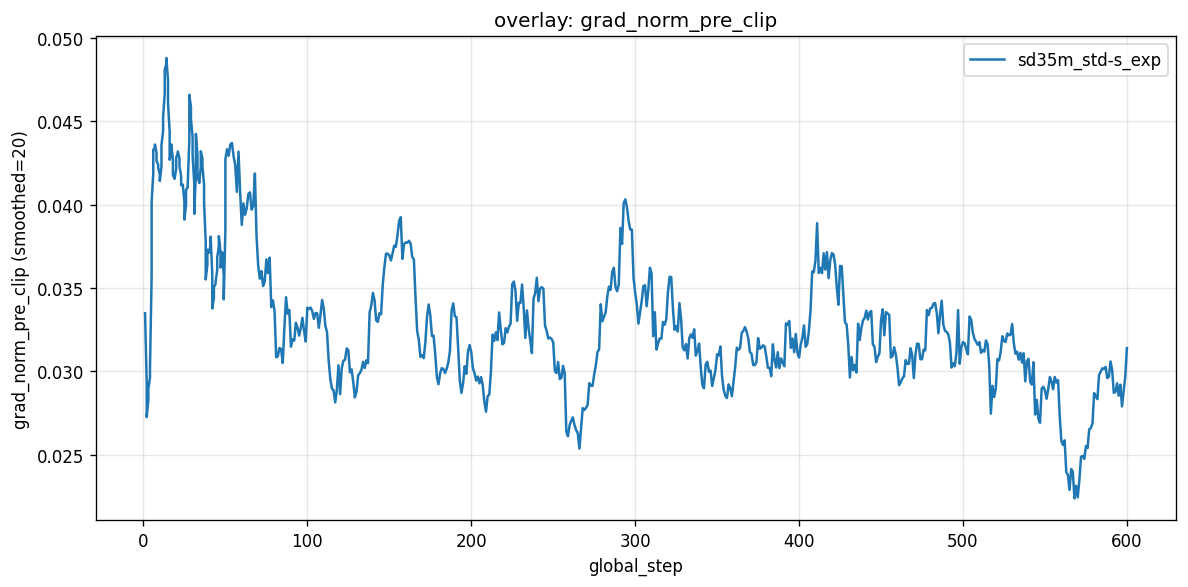

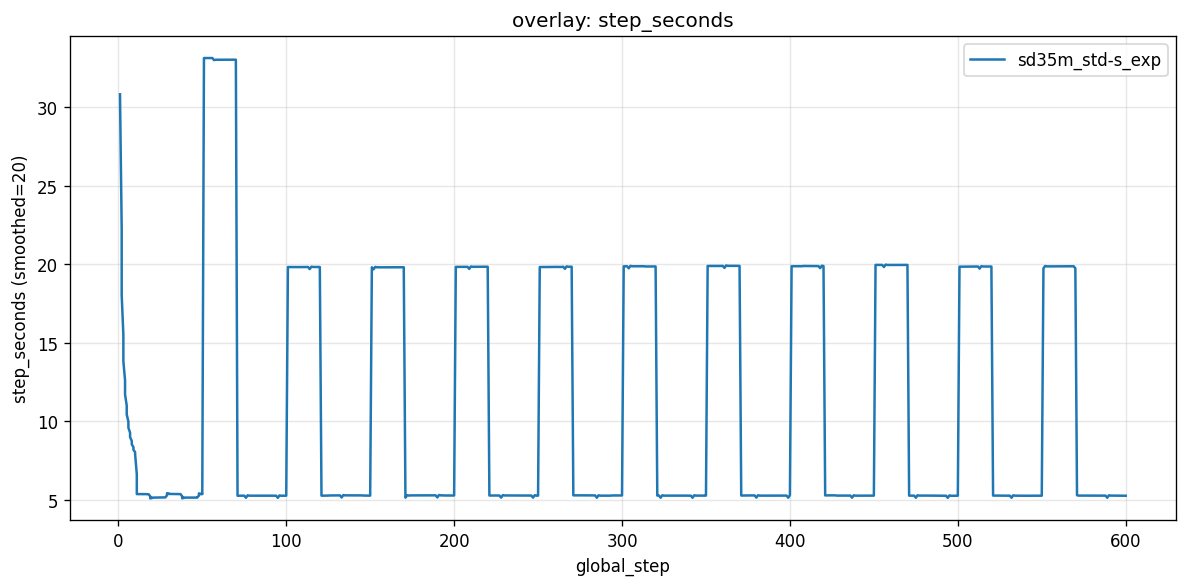

In [90]:
# 多个 run 叠加对比（按指标通用）

from typing import Literal


def overlay_metric(
    runs: list[Path],
    *,
    metric: Literal["loss", "grad_norm_pre_clip", "step_seconds"] = "loss",
    smooth_window: int = 10,
    max_runs: int | None = 6,
    title: str | None = None,
):
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    selected = runs if max_runs is None else runs[:max_runs]
    for run_dir in selected:
        d = load_metrics(run_dir).sort_values("global_step")
        if d.empty:
            continue
        y = (
            d[metric].rolling(smooth_window, min_periods=1).mean()
            if smooth_window and smooth_window > 1
            else d[metric]
        )
        ax.plot(d["global_step"], y, label=run_dir.name)

    ax.set_xlabel("global_step")
    ax.set_ylabel(
        f"{metric} (smoothed={smooth_window})" if smooth_window and smooth_window > 1 else metric
    )
    ax.grid(True, alpha=0.3)

    if ax.lines:
        ax.legend()
    else:
        ax.text(0.5, 0.5, "No data to plot", transform=ax.transAxes, ha="center", va="center")

    if title:
        ax.set_title(title)
    fig.tight_layout()
    return fig


# # 快速预览：loss 合并对比
# overlay_metric(runs, metric="loss", smooth_window=20, title="overlay: loss")

for metric in ["loss", "grad_norm_pre_clip", "step_seconds"]:
    fig = overlay_metric(
        runs,
        metric=metric,  # type: ignore[arg-type]
        smooth_window=OVERLAY_SMOOTH_WINDOW,
        max_runs=None,
        title=f"overlay: {metric}",
    )


In [91]:
# # 保存图：每个 case（run）先独立出图，再输出合并对比图

# SMOOTH_WINDOW = 10
# OVERLAY_SMOOTH_WINDOW = 20

# # 1) 每个 run 单独出图（保存到各自 run_dir/figures/）
# for run_dir in runs:
#     df_run = load_metrics(run_dir)
#     fig_dir = run_dir / "figures"
#     fig_dir.mkdir(parents=True, exist_ok=True)

#     fig = plot_metrics(df_run, smooth_window=SMOOTH_WINDOW, title=str(run_dir.name))
#     out_path = fig_dir / f"metrics_curves_s{SMOOTH_WINDOW}.png"
#     fig.savefig(out_path, bbox_inches="tight")
#     plt.close(fig)
#     print("Saved:", out_path)

# # 2) 合并对比图（统一写到 outputs/_compare_figures/）
# COMPARE_FIG_DIR = OUTPUTS_DIR / "_compare_figures"
# COMPARE_FIG_DIR.mkdir(parents=True, exist_ok=True)

# for metric in ["loss", "grad_norm_pre_clip", "step_seconds"]:
#     fig = overlay_metric(
#         runs,
#         metric=metric,  # type: ignore[arg-type]
#         smooth_window=OVERLAY_SMOOTH_WINDOW,
#         max_runs=None,
#         title=f"overlay: {metric}",
#     )
#     out_path = COMPARE_FIG_DIR / f"overlay_{metric}_s{OVERLAY_SMOOTH_WINDOW}.png"
#     fig.savefig(out_path, bbox_inches="tight")
#     plt.close(fig)
#     print("Saved:", out_path)
